# 📌 Extracción


In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [84]:
df = pd.read_json(url)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


# 🔧 Transformación

In [85]:
# Normalizar datos en distintas columnas
df_dict = df.to_dict(orient="records")
df = pd.json_normalize(df_dict, sep='_')
df

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#### Diccionario de datos

* `customerID`: unique identification number for each customer
* `Churn`: whether or not the customer left the company
* `gender`: gender (male and female)
* `SeniorCitizen`: whether the customer is 65 years old or older
* `Partner`: whether or not the customer has a partner
* `Dependents`: whether or not the customer has dependents
* `tenure`: number of months the customer has been under contract
* `PhoneService`: subscription to phone service
* `MultipleLines`: subscription to more than one phone line
* `InternetService`: subscription to an internet service provider
* `OnlineSecurity`: additional online security subscription
* `OnlineBackup`: additional online backup subscription
* `DeviceProtection`: additional device protection subscription
* `TechSupport`: additional technical support subscription with shorter waiting times
* `StreamingTV`: cable TV subscription
* `StreamingMovies`: movie streaming subscription
* `Contract`: type of contract
* `PaperlessBilling`: whether the customer prefers to receive bills online
* `PaymentMethod`: payment method
* `Charges.Monthly`: total cost of all customer services per month
* `Charges.Total`: total amount spent by the customer


In [86]:
# Revisar tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [87]:
# Revisar dónde faltan datos
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
[(df == '').sum(), df.isna().sum()]

[customerID                     0
 Churn                        224
 customer_gender                0
 customer_SeniorCitizen         0
 customer_Partner               0
 customer_Dependents            0
 customer_tenure                0
 phone_PhoneService             0
 phone_MultipleLines            0
 internet_InternetService       0
 internet_OnlineSecurity        0
 internet_OnlineBackup          0
 internet_DeviceProtection      0
 internet_TechSupport           0
 internet_StreamingTV           0
 internet_StreamingMovies       0
 account_Contract               0
 account_PaperlessBilling       0
 account_PaymentMethod          0
 account_Charges_Monthly        0
 account_Charges_Total         11
 dtype: int64,
 customerID                   0
 Churn                        0
 customer_gender              0
 customer_SeniorCitizen       0
 customer_Partner             0
 customer_Dependents          0
 customer_tenure              0
 phone_PhoneService           0
 phone_Multiple

In [88]:
# Revisar si hay clientes repetidos
df['customerID'].nunique()

7267

In [89]:
# Revisar qué columnas tienen valores binarios 'Yes'/'No'
df.isin(['Yes', 'No']).all()

customerID                   False
Churn                        False
customer_gender              False
customer_SeniorCitizen       False
customer_Partner              True
customer_Dependents           True
customer_tenure              False
phone_PhoneService            True
phone_MultipleLines          False
internet_InternetService     False
internet_OnlineSecurity      False
internet_OnlineBackup        False
internet_DeviceProtection    False
internet_TechSupport         False
internet_StreamingTV         False
internet_StreamingMovies     False
account_Contract             False
account_PaperlessBilling      True
account_PaymentMethod        False
account_Charges_Monthly      False
account_Charges_Total        False
dtype: bool

In [90]:
# Revisar qué columnas tienen valores binarios 0/1
df.isin([0, 1]).all()

customerID                   False
Churn                        False
customer_gender              False
customer_SeniorCitizen        True
customer_Partner             False
customer_Dependents          False
customer_tenure              False
phone_PhoneService           False
phone_MultipleLines          False
internet_InternetService     False
internet_OnlineSecurity      False
internet_OnlineBackup        False
internet_DeviceProtection    False
internet_TechSupport         False
internet_StreamingTV         False
internet_StreamingMovies     False
account_Contract             False
account_PaperlessBilling     False
account_PaymentMethod        False
account_Charges_Monthly      False
account_Charges_Total        False
dtype: bool

# Resultados

+ 224 valores vacíos en `Churn`
+ 11 valores vacíos en `account_Charges_total`
+ Tipo de dato incorrecto en `account_Charges_Total` > valores numéricos
+ No hay clientes repetidos
+ Columnas con solo  1/0 o Yes/No values > boolean
    * `customer_SeniorCitizen`
    * `customer_Partner`
    * `customer_Dependents`
    * `phone_PhoneService`
    * `account_PaperlessBilling`


In [91]:
# Eliminar filas con Churn vacío
df_churn = df[df['Churn'] != ''].copy()

In [92]:
# Reemplazar vacíos en cargos por ceros y cambiar tipo de dato a float
df_churn['account_Charges_Total'] = df_churn['account_Charges_Total'].apply(lambda x: '0' if x == '' else x)
df_churn['account_Charges_Total'] = df_churn['account_Charges_Total'].astype(float)

In [93]:
# Convertir columnas con datos binarios a 0 y 1 para análisis de correlación
cols_to_binary = ['customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'account_PaperlessBilling']
df_churn[cols_to_binary] = df_churn[cols_to_binary].apply(lambda col: col.map({'Yes': 1, 'No': 0}).astype('int'))

In [94]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   int64  
 5   customer_Dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   int64  
 8   phone_MultipleLines        7043 non-null   object 
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   object 
 11  internet_OnlineBackup      7043 non-null   object 
 12  internet_DeviceProtection  7043 non-null   object 
 13  internet_TechSupport       7043 non-null   object 
 1

In [95]:
# Creando columna de cuentas diarias
df_churn['account_Charges_Daily'] = df_churn['account_Charges_Monthly'] / 30

In [96]:
# Renombrar columnas para su comprensión en nuevo df
df_renombrado = df_churn.rename(columns={'Churn':'Cancelación',
                                         'customer_gender':'Género',
                                         'customer_SeniorCitizen':'Adulto mayor',
                                         'customer_Partner':'Con pareja',
                                         'customer_Dependents':'Dependientes',
                                         'customer_tenure': 'Duración',
                                         'phone_PhoneService':'Servicio de teléfono',
                                         'phone_MultipleLines':'Líneas múltiples',
                                         'internet_InternetService':'Servicio de internet',
                                         'internet_OnlineSecurity':'Seguridad en línea',
                                         'internet_OnlineBackup':'Backup en línea',
                                         'internet_DeviceProtection':'Protección de dispositivos',
                                         'internet_TechSupport':'Soporte técnico',
                                         'internet_StreamingTV':'Streaming TV',
                                         'internet_StreamingMovies':'Streaming películas',
                                         'account_Contract':'Contrato',
                                         'account_PaperlessBilling':'Facturación electrónica',
                                         'account_PaymentMethod':'Método de pago',
                                         'account_Charges_Monthly':'Cargos mensuales',
                                         'account_Charges_Total':'Cargos totales',
                                         'account_Charges_Daily':'Cargos diarios'
                                         })

In [97]:
# Conversión de valores binarios en columna Churn también
df_renombrado['Cancelación'] = df_renombrado['Cancelación'].replace({'Yes' : 1, 'No' : 0}).astype('int')

C:\Users\mauri\AppData\Local\Temp\ipykernel_11436\614718228.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_renombrado['Cancelación'] = df_renombrado['Cancelación'].replace({'Yes' : 1, 'No' : 0}).astype('int')


In [98]:
# Buscar datos categóricos para renombrar para su comprensión
for col in df_renombrado.columns:
    if 2 < len(df_renombrado[col].unique()) < 10:
        print(col, df_renombrado[col].unique())

Líneas múltiples ['No' 'Yes' 'No phone service']
Servicio de internet ['DSL' 'Fiber optic' 'No']
Seguridad en línea ['No' 'Yes' 'No internet service']
Backup en línea ['Yes' 'No' 'No internet service']
Protección de dispositivos ['No' 'Yes' 'No internet service']
Soporte técnico ['Yes' 'No' 'No internet service']
Streaming TV ['Yes' 'No' 'No internet service']
Streaming películas ['No' 'Yes' 'No internet service']
Contrato ['One year' 'Month-to-month' 'Two year']
Método de pago ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [99]:
# Renombrar valores de servicios internet
df_renombrado['Servicio de internet'] = df_renombrado['Servicio de internet'].replace({'DSL':'DSL', 'Fiber optic':'Fibra óptica', 'No':'No'})
columnas_internet = ['Seguridad en línea', 'Backup en línea', 'Protección de dispositivos', 'Soporte técnico', 'Streaming TV', 'Streaming películas']
df_renombrado[columnas_internet] = df_renombrado[columnas_internet].replace({'Yes' : 'Sí', 'No' : 'No', 'No internet service':'Sin servicio de internet'})

In [100]:
# Renombrar valores de servicios teléfono
df_renombrado['Líneas múltiples'] = df_renombrado['Líneas múltiples'].replace({'Yes' : 'Sí', 'No' : 'No', 'No phone service':'Sin servicio telefónico'})

In [101]:
# Renombrar tipos de contrato
df_renombrado['Contrato'] = df_renombrado['Contrato'].replace({'One year':'Un año', 'Month-to-month':'Mes a mes', 'Two year':'Dos años'})

In [102]:
# Renombrar métodos de pago
df_renombrado['Método de pago'] = df_renombrado['Método de pago'].replace({'Mailed check' :'Cheque por correo',
                                                                 'Electronic check':'Cheque electrónico',
                                                                 'Credit card (automatic)':'Tarjeta de crédito (automático)',
                                                                 'Bank transfer (automatic)':'Transferencia bancaria (automático)'})

In [103]:
# Renombrar género
df_renombrado['Género'] = df_renombrado['Género'].replace({'Male' :'Hombre', 'Female':'Mujer'})

# 📊 Carga y análisis

In [104]:
# Descripción rápida de los datos numéricos
df_renombrado.describe()

,Cancelación,Adulto mayor,Con pareja,Dependientes,Duración,Servicio de teléfono,Facturación electrónica,Cargos mensuales,Cargos totales,Cargos diarios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


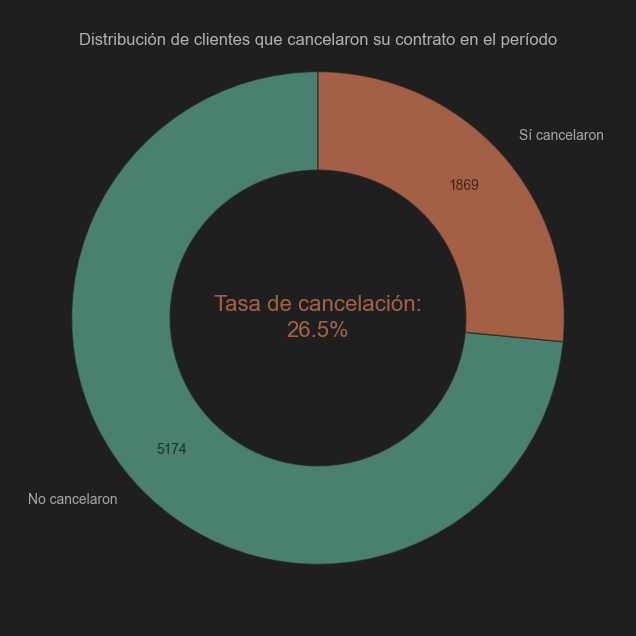

In [106]:
# Distribución de cancelaciones en general
cancelaciones = (df_renombrado['Cancelación'].value_counts().rename(index={1: 'Sí cancelaron', 0: 'No cancelaron'}))

fig, ax = plt.subplots(figsize=(8,8), facecolor='#1f1f1f')

colors = sns.color_palette('Set2', n_colors=len(cancelaciones))

wedges, texts, autotexts = ax.pie(
    cancelaciones,
    labels=cancelaciones.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='#1f1f1f', alpha=0.6),
    pctdistance = 0.8,
    colors=colors
)

for autotext, value in zip(autotexts, cancelaciones):
    autotext.set_text(f'{value}')

ax.text(x=0, y=0,
        horizontalalignment='center',
        verticalalignment='center',
        s=f'Tasa de cancelación:\n{100 * cancelaciones.loc["Sí cancelaron"] / cancelaciones.sum():.1f}%',
        color=sns.color_palette('Set2')[1],
        size=16,
        linespacing=1.4,
        alpha=0.6
        )

for t in texts:
    t.set_color('white')
    t.set_alpha(0.6)

for t in autotexts:
    t.set_color('black')
    t.set_alpha(0.6)

ax.set_title('Distribución de clientes que cancelaron su contrato en el período', y=0.93, color='white', alpha=0.65)

plt.show()

In [108]:
# Distribución de la evasión por perfil del cliente
df_clientes = pd.pivot_table(df_renombrado,
                             values='Cancelación',
                             index=['Género', 'Con pareja', 'Adulto mayor', 'Dependientes'],
                             aggfunc=['count', 'mean']
                             )

df_clientes.columns = [f'{a}_{b}' for a,b in df_clientes.columns]
df_clientes = df_clientes.rename(columns={'mean_Cancelación':'Tasa de cancelación', 'count_Cancelación' : 'Cancelaciones'}, index={1:'Sí', 0:'No'})

df_clientes_estilo = df_clientes.style
df_clientes_estilo.format({'Tasa de cancelación':'{:.1%}'})
df_clientes_estilo.background_gradient(cmap='RdYlGn_r', subset=['Tasa de cancelación'])

df_clientes_estilo


In [109]:
# Código de la tabla para el informe
print(df_clientes_estilo.to_html())

<style type="text/css">
#T_5aee6_row0_col1 {
  background-color: #f4fab0;
  color: #000000;
}
#T_5aee6_row1_col1 {
  background-color: #69be63;
  color: #f1f1f1;
}
#T_5aee6_row2_col1 {
  background-color: #b91326;
  color: #f1f1f1;
}
#T_5aee6_row3_col1 {
  background-color: #60ba62;
  color: #f1f1f1;
}
#T_5aee6_row4_col1, #T_5aee6_row9_col1 {
  background-color: #8ecf67;
  color: #000000;
}
#T_5aee6_row5_col1 {
  background-color: #006837;
  color: #f1f1f1;
}
#T_5aee6_row6_col1 {
  background-color: #fdc171;
  color: #000000;
}
#T_5aee6_row7_col1 {
  background-color: #d5ed88;
  color: #000000;
}
#T_5aee6_row8_col1 {
  background-color: #fff8b4;
  color: #000000;
}
#T_5aee6_row10_col1 {
  background-color: #a50026;
  color: #f1f1f1;
}
#T_5aee6_row11_col1 {
  background-color: #feefa3;
  color: #000000;
}
#T_5aee6_row12_col1 {
  background-color: #4eb15d;
  color: #f1f1f1;
}
#T_5aee6_row13_col1 {
  background-color: #0d8044;
  color: #f1f1f1;
}
#T_5aee6_row14_col1 {
  background-color: 

In [110]:
df_renombrado.sample(10)

,customerID,Cancelación,Género,Adulto mayor,Con pareja,Dependientes,Duración,Servicio de teléfono,Líneas múltiples,Servicio de internet,...,Protección de dispositivos,Soporte técnico,Streaming TV,Streaming películas,Contrato,Facturación electrónica,Método de pago,Cargos mensuales,Cargos totales,Cargos diarios
4314,5924-IFQTT,0,Hombre,0,1,1,13,1,Sí,DSL,...,Sí,Sí,Sí,No,Mes a mes,1,Cheque electrónico,72.80,930.05,2.426667
1522,2189-UXTKY,1,Mujer,0,1,0,22,1,Sí,DSL,...,No,Sí,Sí,Sí,Mes a mes,1,Cheque electrónico,79.20,1742.75,2.640000
3691,5088-QZLRL,0,Hombre,0,0,0,1,1,No,No,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,0,Cheque electrónico,20.65,20.65,0.688333
3194,4459-BBGHE,0,Hombre,0,0,1,30,0,Sin servicio telefónico,DSL,...,No,No,Sí,Sí,Mes a mes,1,Cheque electrónico,44.50,1307.80,1.483333
170,0266-GMEAO,0,Hombre,0,1,1,72,1,Sí,Fibra óptica,...,Sí,Sí,Sí,Sí,Dos años,1,Tarjeta de crédito (automático),114.30,8058.55,3.810000
5952,8129-GMVGI,0,Mujer,0,1,1,56,1,No,No,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Dos años,0,Cheque por correo,20.05,1090.10,0.668333
3428,4749-OJKQU,0,Mujer,0,0,0,4,1,Sí,Fibra óptica,...,No,No,No,No,Mes a mes,1,Cheque electrónico,75.65,302.35,2.521667
5083,6950-TWMYB,0,Hombre,0,1,1,54,1,No,Fibra óptica,...,No,Sí,No,No,Dos años,1,Transferencia bancaria (automático),79.95,4362.05,2.665000
334,0486-HECZI,1,Hombre,0,1,0,55,1,Sí,Fibra óptica,...,No,No,Sí,No,Mes a mes,1,Cheque electrónico,96.75,5238.90,3.225000
6754,9313-CDOGY,0,Hombre,0,1,1,38,1,No,No,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,0,Cheque electrónico,19.60,717.30,0.653333


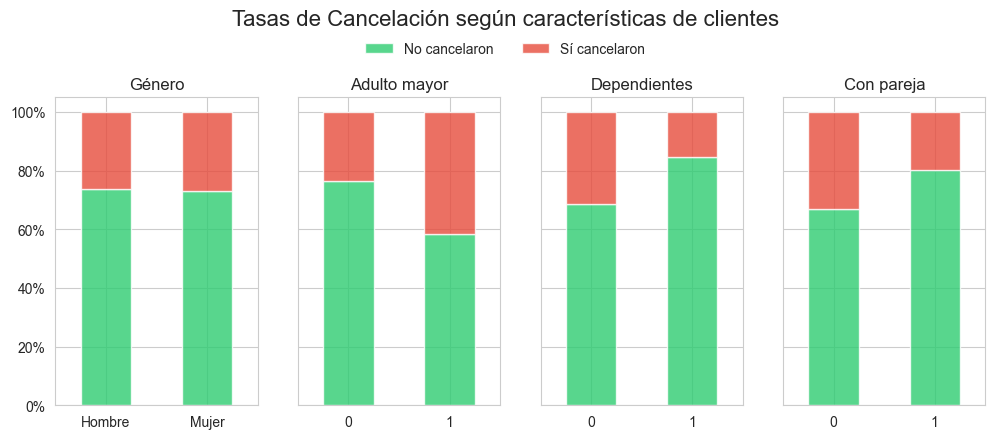

In [111]:
# Comparación de clientes según sus características
caracteristicas_clientes = ['Género', 'Adulto mayor', 'Dependientes', 'Con pareja']

# Barras apiladas para cada categoría
fig, axes = plt.subplots(nrows=1, ncols=len(caracteristicas_clientes), figsize=(12, 4), sharey=True)
fig.suptitle('Tasas de Cancelación según características de clientes', fontsize=16, y=1.1)

for i, col in enumerate(caracteristicas_clientes):

    df_plot = pd.crosstab(df_renombrado[col], df['Churn'], normalize='index') * 100
    df_plot.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], alpha=0.8, legend=False)

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.05),
           loc='upper center', ncol=2, frameon=False)
plt.show()

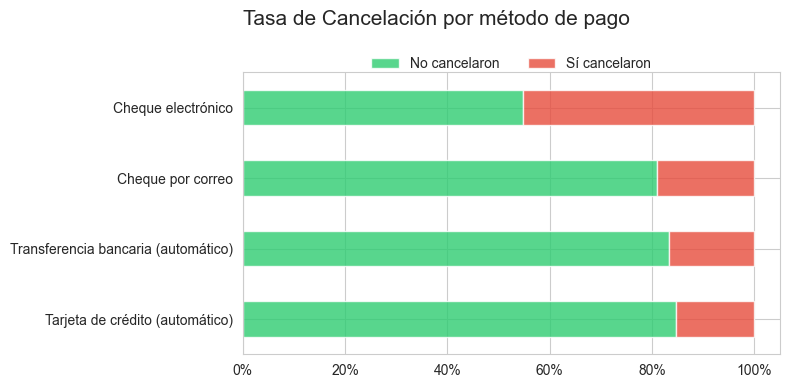

In [112]:
# Distribución de la evasión por método de pago
tabla_pago = pd.crosstab(df_renombrado['Método de pago'],
                         df_renombrado['Cancelación'],
                         normalize='index') * 100

# Ordenar de mayor a menor tasa de cancelación para que el gráfico sea más revelador
tabla_pago = tabla_pago.sort_values(by=1, ascending=True)

ax = tabla_pago.plot(kind='barh',
                     stacked=True,
                     figsize=(8, 4),
                     color=['#2ecc71', '#e74c3c'],
                     legend=False,
                     alpha=0.8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.title('Tasa de Cancelación por método de pago', loc='left', fontsize=15, pad=20, y=1.07)
plt.ylabel('')
plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.1),
           loc='upper center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

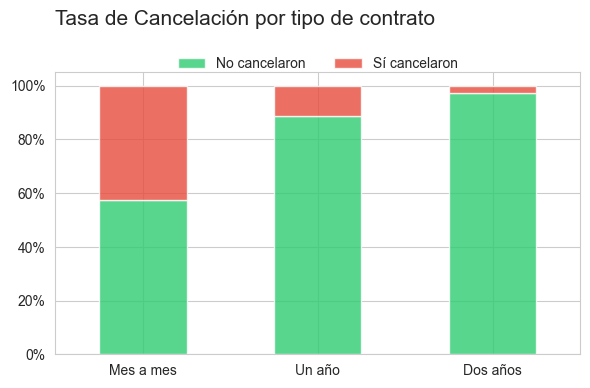

In [113]:
# Distribución de la evasión por duración de contrato
tabla_contrato = pd.crosstab(df_renombrado['Contrato'],
                             df_renombrado['Cancelación'],
                             normalize='index') * 100

tabla_contrato = tabla_contrato.sort_values(by=1, ascending=False)

# 3. Graficar en barras verticales (kind='bar')
ax = tabla_contrato.plot(kind='bar',
                         stacked=True,
                         figsize=(6, 4),
                         color=['#2ecc71', '#e74c3c'],
                         legend=False,
                         alpha=0.8)

# Configuración de títulos y etiquetas siguiendo tu diseño
plt.title('Tasa de Cancelación por tipo de contrato', loc='left', fontsize=15, pad=20, y=1.07)
plt.xlabel('')
plt.xticks(rotation=0) # Asegura que los nombres de los contratos se lean horizontalmente

# El formateador de porcentaje ahora va en el eje Y
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Leyenda global superior
plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.1),
           loc='upper center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

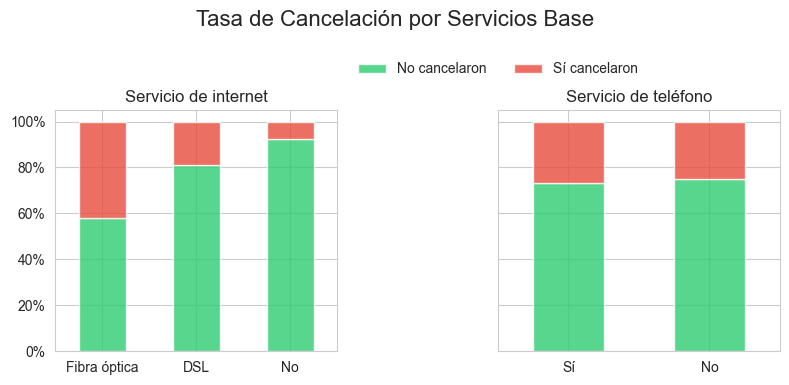

In [114]:
# Distribución de la evasión según  servicio de internet y de teléfono
servicios_principales = ['Servicio de internet', 'Servicio de teléfono']
mapeo_tel = {0: 'No', 1: 'Sí', '0': 'No', '1': 'Sí'}

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
fig.suptitle('Tasa de Cancelación por Servicios Base', fontsize=16, y=0.95)

for i, col in enumerate(servicios_principales):
    df_temp = df_renombrado.copy()
    if col == 'Servicio de teléfono':
        df_temp[col] = df_temp[col].replace(mapeo_tel)

    tabla = pd.crosstab(df_temp[col], df_temp['Cancelación'], normalize='index') * 100
    tabla = tabla.sort_values(by=1, ascending=False)

    tabla.plot(kind='bar', stacked=True, ax=axes[i],
               color=['#2ecc71', '#e74c3c'], alpha=0.8, legend=False)

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0, 1.25),
           loc='upper center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

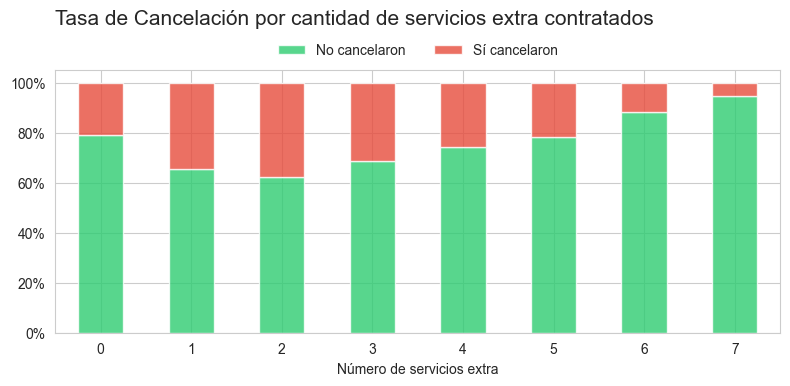

In [115]:
# Distribución de la evasión según  cantidad de servicios extra
servicios_extra = ['Protección de dispositivos', 'Seguridad en línea', 'Backup en línea',
                   'Soporte técnico', 'Streaming TV', 'Streaming películas']

# Suma: Internet (si tiene) + Teléfono (si tiene) + Líneas múltiples + Extras
df_renombrado['Total_Servicios_Extra'] = (
    (df_renombrado['Líneas múltiples'] == 'Sí').astype(int) +
    df_renombrado[servicios_extra].apply(lambda x: x == 'Sí').sum(axis=1)
)

tabla_suma = pd.crosstab(df_renombrado['Total_Servicios_Extra'],
                         df_renombrado['Cancelación'], normalize='index') * 100

ax = tabla_suma.plot(kind='bar', stacked=True, figsize=(8, 4),
                     color=['#2ecc71', '#e74c3c'], alpha=0.8, legend=False)

plt.title('Tasa de Cancelación por cantidad de servicios extra contratados',
          loc='left', fontsize=15, pad=20, y=1.07)
plt.xlabel('Número de servicios extra')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.15),
           loc='upper center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [116]:
df_renombrado

,customerID,Cancelación,Género,Adulto mayor,Con pareja,Dependientes,Duración,Servicio de teléfono,Líneas múltiples,Servicio de internet,...,Soporte técnico,Streaming TV,Streaming películas,Contrato,Facturación electrónica,Método de pago,Cargos mensuales,Cargos totales,Cargos diarios,Total_Servicios_Extra
0,0002-ORFBO,0,Mujer,0,1,1,9,1,No,DSL,...,Sí,Sí,No,Un año,1,Cheque por correo,65.60,593.30,2.186667,3
1,0003-MKNFE,0,Hombre,0,0,0,9,1,Sí,DSL,...,No,No,Sí,Mes a mes,0,Cheque por correo,59.90,542.40,1.996667,2
2,0004-TLHLJ,1,Hombre,0,0,0,4,1,No,Fibra óptica,...,No,No,No,Mes a mes,1,Cheque electrónico,73.90,280.85,2.463333,1
3,0011-IGKFF,1,Hombre,1,1,0,13,1,No,Fibra óptica,...,No,Sí,Sí,Mes a mes,1,Cheque electrónico,98.00,1237.85,3.266667,4
4,0013-EXCHZ,1,Mujer,1,1,0,3,1,No,Fibra óptica,...,Sí,Sí,No,Mes a mes,1,Cheque por correo,83.90,267.40,2.796667,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Mujer,0,0,0,13,1,No,DSL,...,Sí,No,No,Un año,0,Cheque por correo,55.15,742.90,1.838333,2
7263,9992-RRAMN,1,Hombre,0,1,0,22,1,Sí,Fibra óptica,...,No,No,Sí,Mes a mes,1,Cheque electrónico,85.10,1873.70,2.836667,2
7264,9992-UJOEL,0,Hombre,0,0,0,2,1,No,DSL,...,No,No,No,Mes a mes,1,Cheque por correo,50.30,92.75,1.676667,1
7265,9993-LHIEB,0,Hombre,0,1,1,67,1,No,DSL,...,Sí,No,Sí,Dos años,0,Cheque por correo,67.85,4627.65,2.261667,4


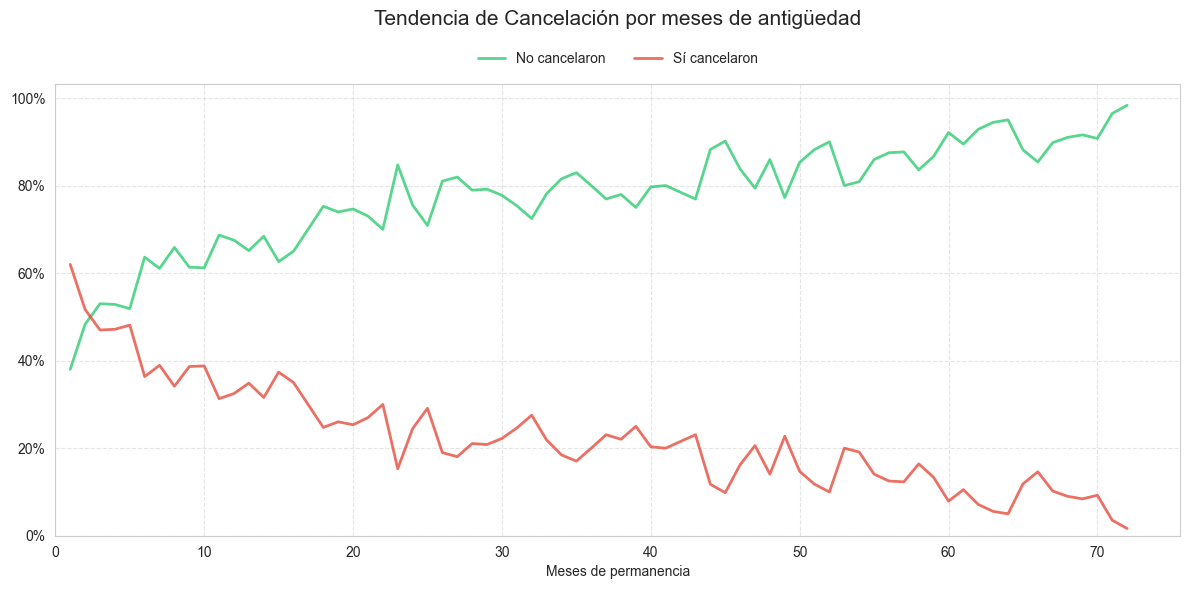

In [117]:
tabla_duracion = pd.crosstab(df_renombrado['Duración'],
                             df_renombrado['Cancelación'],
                             normalize='index') * 100

ax = tabla_duracion.iloc[1:].plot(kind='line',
                         figsize=(12, 6),
                         color=['#2ecc71', '#e74c3c'],
                         alpha=0.8,
                         linewidth=2)

plt.title('Tendencia de Cancelación por meses de antigüedad', loc='center', fontsize=15, pad=20, y=1.07)
plt.xlabel('Meses de permanencia')
plt.ylabel('')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.1),
           loc='upper center', ncol=2, frameon=False)
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

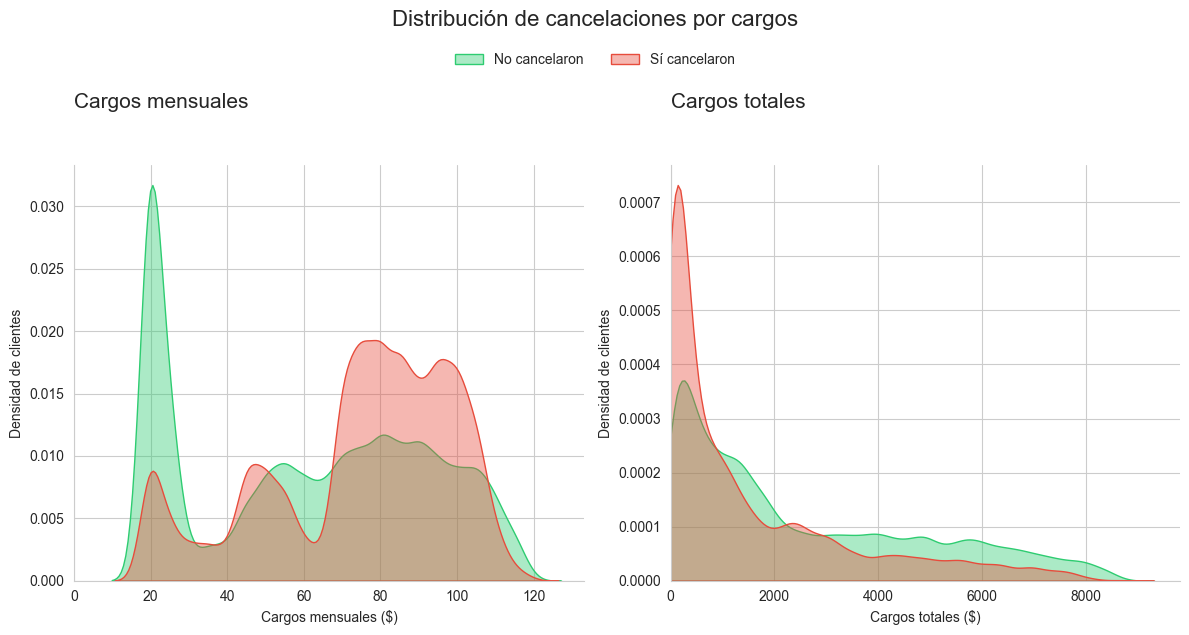

In [118]:
# Distribución de cancelaciones por cargos mensuales y totales
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

columnas_gasto = ['Cargos mensuales', 'Cargos totales']

for i, col in enumerate(columnas_gasto):
    sns.kdeplot(df_renombrado[df_renombrado['Cancelación'] == 0][col],
                bw_adjust=0.5, ax=axes[i], fill=True,
                color='#2ecc71', alpha=0.4, label='No cancelaron')

    sns.kdeplot(df_renombrado[df_renombrado['Cancelación'] == 1][col],
                bw_adjust=0.5, ax=axes[i], fill=True,
                color='#e74c3c', alpha=0.4, label='Sí cancelaron')

    axes[i].set_title(col, loc='left', fontsize=15, pad=20, y=1.07)
    axes[i].set_xlabel(f'{col} ($)')
    axes[i].set_ylabel('Densidad de clientes')
    axes[i].set_xlim(left=0) # Empezar en 0,0

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle('Distribución de cancelaciones por cargos', fontsize=16, y=1.05)
fig.legend(handles, ['No cancelaron', 'Sí cancelaron'],
           bbox_to_anchor=(0.5, 1), loc='upper center',
           ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [125]:
# Análisis de correlaciones de las variables

# Convertir servicio de internet en variable numérica
df_renombrado = pd.get_dummies(df_renombrado, columns=['Servicio de internet'], prefix='internet', drop_first=False) # using prefix for clear column names
corr = df_renombrado.drop(columns=['Cargos diarios']).corr(numeric_only=True)
corr

,Cancelación,Adulto mayor,Con pareja,Dependientes,Duración,Servicio de teléfono,Facturación electrónica,Cargos mensuales,Cargos totales,Total_Servicios_Extra,internet_DSL,internet_Fibra óptica,internet_No
Cancelación,1.000000,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.198324,-0.069533,-0.124214,0.308020,-0.227890
Adulto mayor,0.150889,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.103006,0.095479,-0.108322,0.255338,-0.182742
Con pareja,-0.150448,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.317504,0.218781,-0.000851,0.000304,0.000615
Dependientes,-0.164221,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.062078,0.021357,0.052010,-0.165818,0.139812
Duración,-0.352229,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.826178,0.526600,0.013274,0.019720,-0.039062
Servicio de teléfono,0.011942,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113214,-0.016303,-0.452425,0.289999,0.172209
Facturación electrónica,0.191825,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.158574,0.204314,-0.063121,0.326853,-0.321013
Cargos mensuales,0.193356,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.651174,0.773021,-0.160189,0.787066,-0.763557
Cargos totales,-0.198324,0.103006,0.317504,0.062078,0.826178,0.113214,0.158574,0.651174,1.000000,0.785901,-0.052469,0.361655,-0.375223
Total_Servicios_Extra,-0.069533,0.095479,0.218781,0.021357,0.526600,-0.016303,0.204314,0.773021,0.785901,1.000000,0.172893,0.311692,-0.574843


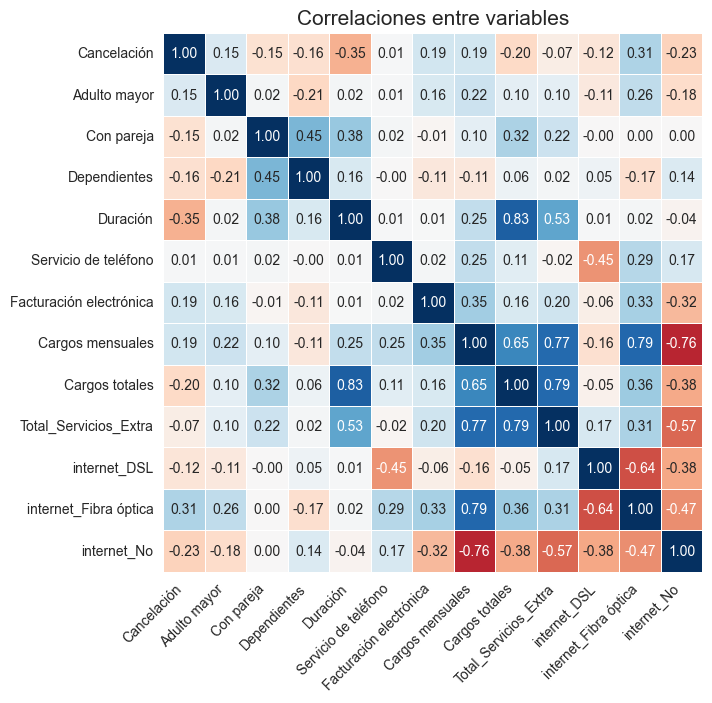

In [128]:
# Mapa de calor de las correlaciones entre variables

plt.figure(figsize=(8, 7))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap='RdBu',
            center=0,
            square=True,
            linewidths=.5,
            cbar=False)

plt.title('Correlaciones entre variables', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.show()

# Informe Final

### Introducción

Se realiza un análisis del dataset de Telecom X para obtener insights sobre los motivos de las **cancelaciones** de servicio por parte de los clientes, en base a las  características de los clientes y de los contratos que mantienen. Para esto se analizan las variables pertinentes cada una con respecto a la evasión o cancelación, así como si hay alguna **correlación** o **patrones** que nos ayuden a identificar puntos que se puedan tomar en cuenta para las estrategias de negocio.

### Limpieza y Tratamiento de Datos

Se carga el dataset desde un archivo JSON por medio de la librería de Pandas y se normalizan lso datos para obtener una tabla o DataFrame con todos los datos expandidos para su análisis. Se revisan las características del dataset para entender el tipo de datos que manejan y las distintas variables disponibles.

Posteriormente, se revisan los datos para encontrar datos faltantes o repetidos. Al encontrar valores nulos en la columna de 'Churn' y dado que estos registros no cuentan con la etiqueta necesaria para el análisis de abandono, se procedió con la eliminación de las filas correspondientes para asegurar la integridad de las correlaciones. Los valores nulos en la variables de 'Cargos totales' se explican como inexistentes debido a que no se han generado aún cargos para estos clientes, así que se convierten a ceros y se hace al cambio de tipo a un avariable numérica para su uso en el análisis. Se realiza también el cambio de las variables de naturaleza binaria (Sí/No) a valores numéricos (0/1) con este mismo fin.

### Análisis Exploratorio de Datos

Se crean gráficos para comparar cada variable significativa con la tasa de cancelación de los clientes y así conocer los posibles motivos o factores más importantes que expliquen por qué los clientes cancelan su servicio o no:
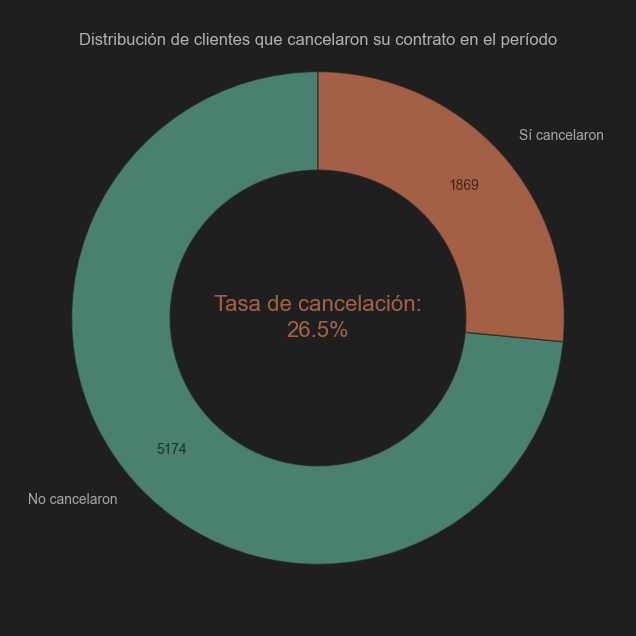

La tasa de cancelación llega al 26.5%

![Tasa de cancelación general](visuals/tasa_cancelacion.png)


No hay diferencia notable en las cancelaciones dependiendo del género del cliente, lo que sí es notable es que los que no tienen dependientes y los adultos mayores tienden a cancelar en mayor medida.

<style type="text/css">
#T_cc34d_row0_col1 {
  background-color: #f4fab0;
  color: #000000;
}
#T_cc34d_row1_col1 {
  background-color: #69be63;
  color: #f1f1f1;
}
#T_cc34d_row2_col1 {
  background-color: #b91326;
  color: #f1f1f1;
}
#T_cc34d_row3_col1 {
  background-color: #60ba62;
  color: #f1f1f1;
}
#T_cc34d_row4_col1, #T_cc34d_row9_col1 {
  background-color: #8ecf67;
  color: #000000;
}
#T_cc34d_row5_col1 {
  background-color: #006837;
  color: #f1f1f1;
}
#T_cc34d_row6_col1 {
  background-color: #fdc171;
  color: #000000;
}
#T_cc34d_row7_col1 {
  background-color: #d5ed88;
  color: #000000;
}
#T_cc34d_row8_col1 {
  background-color: #fff8b4;
  color: #000000;
}
#T_cc34d_row10_col1 {
  background-color: #a50026;
  color: #f1f1f1;
}
#T_cc34d_row11_col1 {
  background-color: #feefa3;
  color: #000000;
}
#T_cc34d_row12_col1 {
  background-color: #4eb15d;
  color: #f1f1f1;
}
#T_cc34d_row13_col1 {
  background-color: #0d8044;
  color: #f1f1f1;
}
#T_cc34d_row14_col1 {
  background-color: #fee08b;
  color: #000000;
}
#T_cc34d_row15_col1 {
  background-color: #6bbf64;
  color: #000000;
}
</style>
<table id="T_cc34d">
  <thead>
    <tr>
      <th class="blank" >&nbsp;</th>
      <th class="blank" >&nbsp;</th>
      <th class="blank" >&nbsp;</th>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_cc34d_level0_col0" class="col_heading level0 col0" >Cancelaciones</th>
      <th id="T_cc34d_level0_col1" class="col_heading level0 col1" >Tasa de cancelación</th>
    </tr>
    <tr>
      <th class="index_name level0" >Género</th>
      <th class="index_name level1" >Con pareja</th>
      <th class="index_name level2" >Adulto mayor</th>
      <th class="index_name level3" >Dependientes</th>
      <th class="blank col0" >&nbsp;</th>
      <th class="blank col1" >&nbsp;</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_cc34d_level0_row0" class="row_heading level0 row0" rowspan="8">Hombre</th>
      <th id="T_cc34d_level1_row0" class="row_heading level1 row0" rowspan="4">No</th>
      <th id="T_cc34d_level2_row0" class="row_heading level2 row0" rowspan="2">No</th>
      <th id="T_cc34d_level3_row0" class="row_heading level3 row0" >No</th>
      <td id="T_cc34d_row0_col0" class="data row0 col0" >1381</td>
      <td id="T_cc34d_row0_col1" class="data row0 col1" >30.3%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level3_row1" class="row_heading level3 row1" >Sí</th>
      <td id="T_cc34d_row1_col0" class="data row1 col0" >211</td>
      <td id="T_cc34d_row1_col1" class="data row1 col1" >20.4%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level2_row2" class="row_heading level2 row2" rowspan="2">Sí</th>
      <th id="T_cc34d_level3_row2" class="row_heading level3 row2" >No</th>
      <td id="T_cc34d_row2_col0" class="data row2 col0" >244</td>
      <td id="T_cc34d_row2_col1" class="data row2 col1" >48.4%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level3_row3" class="row_heading level3 row3" >Sí</th>
      <td id="T_cc34d_row3_col0" class="data row3 col0" >5</td>
      <td id="T_cc34d_row3_col1" class="data row3 col1" >20.0%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level1_row4" class="row_heading level1 row4" rowspan="4">Sí</th>
      <th id="T_cc34d_level2_row4" class="row_heading level2 row4" rowspan="2">No</th>
      <th id="T_cc34d_level3_row4" class="row_heading level3 row4" >No</th>
      <td id="T_cc34d_row4_col0" class="data row4 col0" >567</td>
      <td id="T_cc34d_row4_col1" class="data row4 col1" >22.6%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level3_row5" class="row_heading level3 row5" >Sí</th>
      <td id="T_cc34d_row5_col0" class="data row5 col0" >822</td>
      <td id="T_cc34d_row5_col1" class="data row5 col1" >12.8%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level2_row6" class="row_heading level2 row6" rowspan="2">Sí</th>
      <th id="T_cc34d_level3_row6" class="row_heading level3 row6" >No</th>
      <td id="T_cc34d_row6_col0" class="data row6 col0" >281</td>
      <td id="T_cc34d_row6_col1" class="data row6 col1" >37.4%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level3_row7" class="row_heading level3 row7" >Sí</th>
      <td id="T_cc34d_row7_col0" class="data row7 col0" >44</td>
      <td id="T_cc34d_row7_col1" class="data row7 col1" >27.3%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level0_row8" class="row_heading level0 row8" rowspan="8">Mujer</th>
      <th id="T_cc34d_level1_row8" class="row_heading level1 row8" rowspan="4">No</th>
      <th id="T_cc34d_level2_row8" class="row_heading level2 row8" rowspan="2">No</th>
      <th id="T_cc34d_level3_row8" class="row_heading level3 row8" >No</th>
      <td id="T_cc34d_row8_col0" class="data row8 col0" >1338</td>
      <td id="T_cc34d_row8_col1" class="data row8 col1" >32.1%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level3_row9" class="row_heading level3 row9" >Sí</th>
      <td id="T_cc34d_row9_col0" class="data row9 col0" >142</td>
      <td id="T_cc34d_row9_col1" class="data row9 col1" >22.5%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level2_row10" class="row_heading level2 row10" rowspan="2">Sí</th>
      <th id="T_cc34d_level3_row10" class="row_heading level3 row10" >No</th>
      <td id="T_cc34d_row10_col0" class="data row10 col0" >317</td>
      <td id="T_cc34d_row10_col1" class="data row10 col1" >49.8%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level3_row11" class="row_heading level3 row11" >Sí</th>
      <td id="T_cc34d_row11_col0" class="data row11 col0" >3</td>
      <td id="T_cc34d_row11_col1" class="data row11 col1" >33.3%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level1_row12" class="row_heading level1 row12" rowspan="4">Sí</th>
      <th id="T_cc34d_level2_row12" class="row_heading level2 row12" rowspan="2">No</th>
      <th id="T_cc34d_level3_row12" class="row_heading level3 row12" >No</th>
      <td id="T_cc34d_row12_col0" class="data row12 col0" >596</td>
      <td id="T_cc34d_row12_col1" class="data row12 col1" >19.1%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level3_row13" class="row_heading level3 row13" >Sí</th>
      <td id="T_cc34d_row13_col0" class="data row13 col0" >844</td>
      <td id="T_cc34d_row13_col1" class="data row13 col1" >14.7%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level2_row14" class="row_heading level2 row14" rowspan="2">Sí</th>
      <th id="T_cc34d_level3_row14" class="row_heading level3 row14" >No</th>
      <td id="T_cc34d_row14_col0" class="data row14 col0" >209</td>
      <td id="T_cc34d_row14_col1" class="data row14 col1" >34.9%</td>
    </tr>
    <tr>
      <th id="T_cc34d_level3_row15" class="row_heading level3 row15" >Sí</th>
      <td id="T_cc34d_row15_col0" class="data row15 col0" >39</td>
      <td id="T_cc34d_row15_col1" class="data row15 col1" >20.5%</td>
    </tr>
  </tbody>
</table>


Visualizando cada categoría de clientes por separado confirmamos estos puntos.

![Tasa de cancelación por caracteristicas de clientes](visuals/cancelacion_clientes.png)
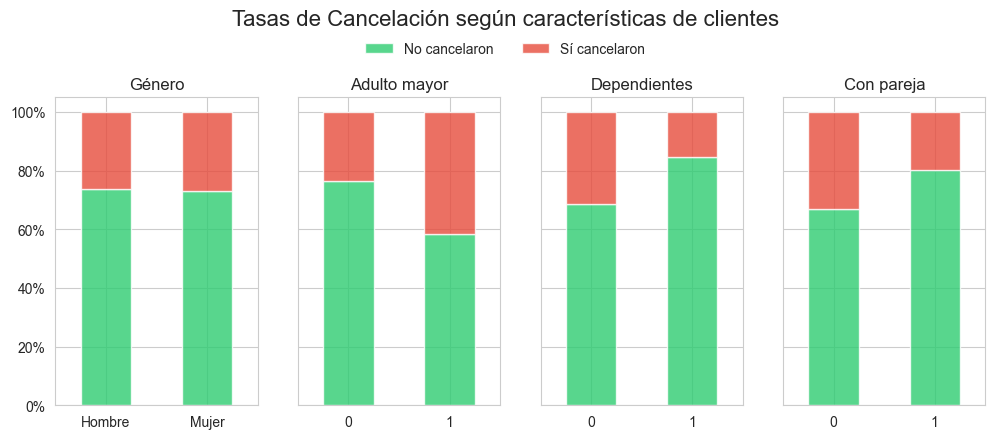

En las variables referentes a los servicios mismos encontramos otros insights.

Todos los métodos de pago presentan más o menos la misma tasa de cancelación excepto mediante cheque electrónico, que tiene más del doble que los demás.

![Cancelaciones por método de pago](visuals/cancelacion_metodo_pago.png)
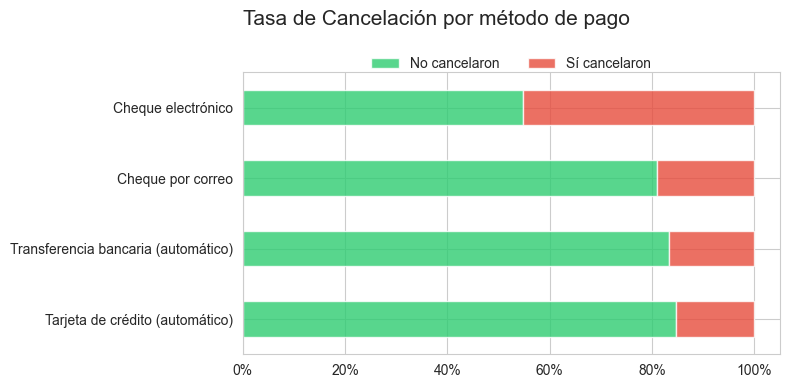

El tiempo de contrato muestra que mientras más corto es el contrato es más probale que haya una cancelación, lo cual tiene sentido y no es necesariamente útil.

![Cancelaciones por tipo de contrato](visuals/cancelacion_tipo_contrato.png)
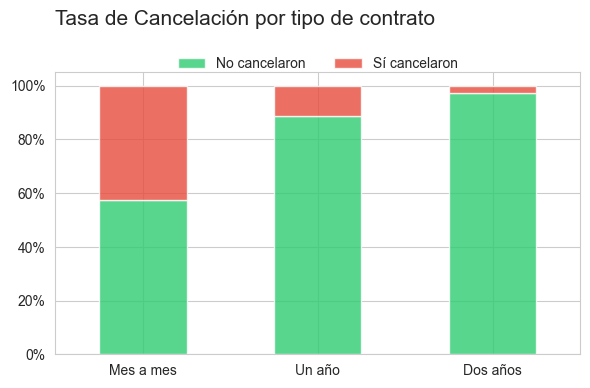

En cuanto al servicio principal contratado, tener servicio de teléfono no tiene mucho impacto en la cancelación, mientras que el de internet muestra que por Fibra óptica la tasa de cancelaciones es más del doble que por DSL, quizá reflejando un mal servicio por ese medio, y que los clientes sin servicio de internet son muy estables, con menos del 10% de cancelaciones.

![Cancelaciones por servicio base](visuals/cancelacion_servicios_base.png)
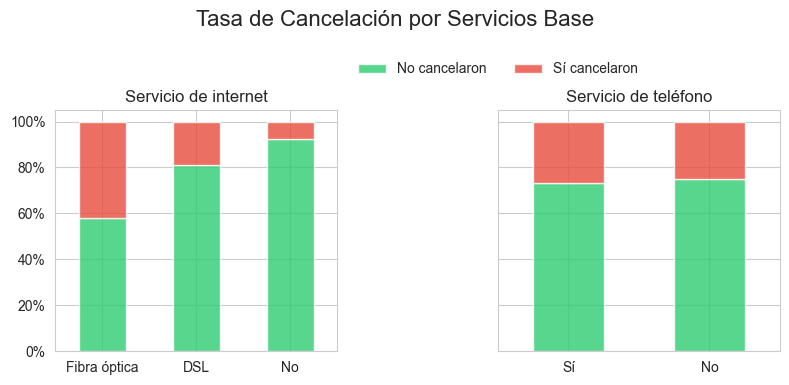

La cantidad de servicios contratados nos indica una tendencia a mayor cancelación a cuando hay uno o dos servicios extra contratados, y bajando progresivamente mientras más servicios extra se tengan. Esto puede indicar una mayor fidelización de los clientes que dependen de más servicios.

![Cancelaciones por cantidad de servicios extras](visuals/cancelacion_servicios_extras.png)
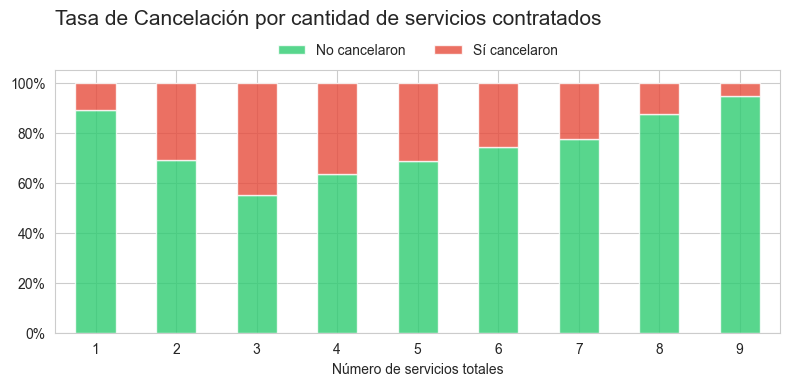
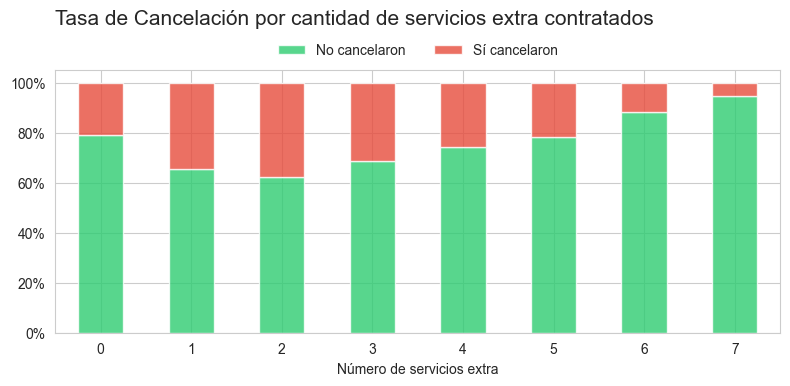

Al analizar la duración de los contratos, vemos que los clientes tienden a cancelar menos cuanto más tiempo lleven con la empresa, mostrando una tendencia casi lineal a la baja en cancelaciones según pasen los meses de contrato.

![Cancelaciones por meses de antiguedad](visuals/cancelacion_antiguedad.png)
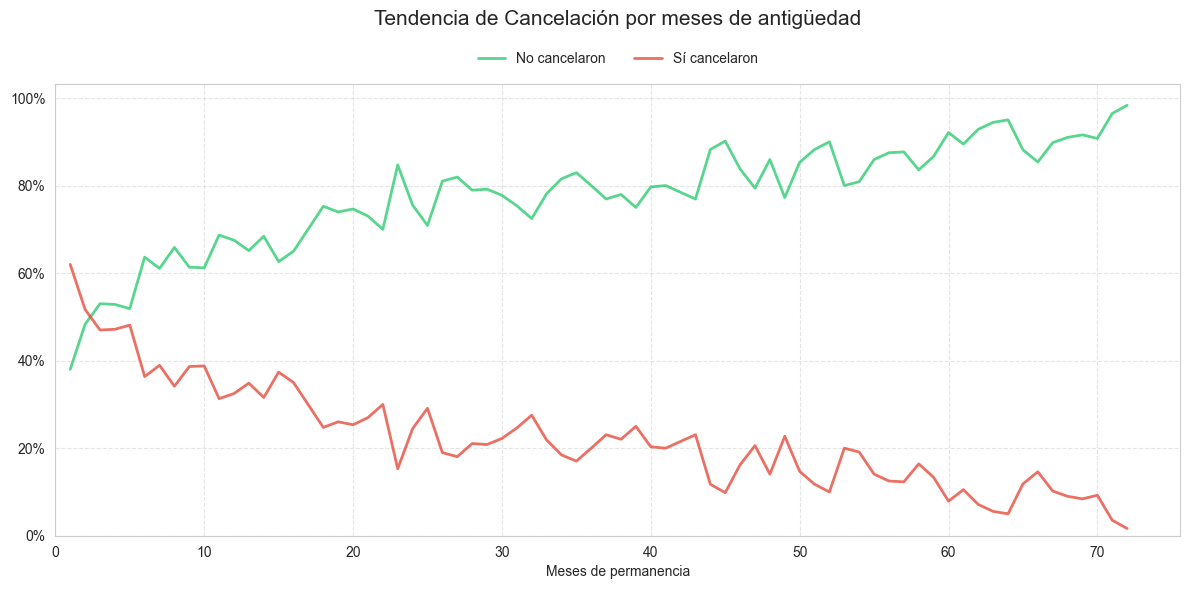

Un dato interesante analizando los cargos mensuales y totales, es que mientras más ha gastado un cliente en su servicio a través del tiempo, menos probable es que cancele, consolidando lo que vimos anteriormente respecto de que a mayor duración y mayor cantidad de servicios, las cancelaciones bajan. En cambio en los cargos mensuales, vemos que los clientes se distribuyen con menores cancelaciones cuando pagan las menores cantidades con un pico en los \\$20, siendo probablemente los que solo contrataron un servicio básico, y en cambio aumentando considerablemente la tasa de cancelación en los que pagan entre \\$70 y \\$100.

![Cancelaciones por cargos mensuales y totales](visuals/cancelacion_cargos.png)
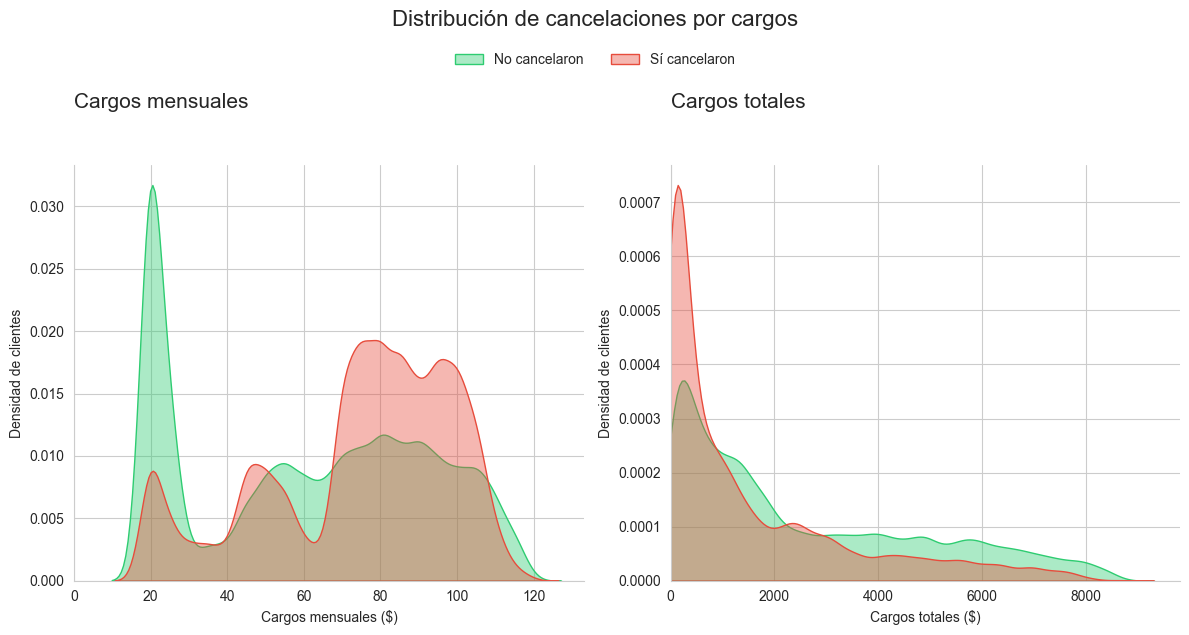

Al hacer un análisis de correlaciones entre las distintas variables, confirmamos algunas de las observaciones anteriores, y obtenemos otros insights más específicos:

![Mapa de calor de correlaciones entre variables](visuals/mapa_correlaciones.png)

Los gastos totales y la cantidad de servicios extra sí están ligados con la antigüedad del cliente (**0.83** y **0.53** respectivamente). Los clientes con Fibra óptica tienen cargos mensuales mucho mayores que los que tienen DSL (**0.79** contra **-0.16**), pero la misma duración (**0.02** contra **0.01**), además los clientes con DSL tienden a no contratar servicio de teléfono (**-0.45**).
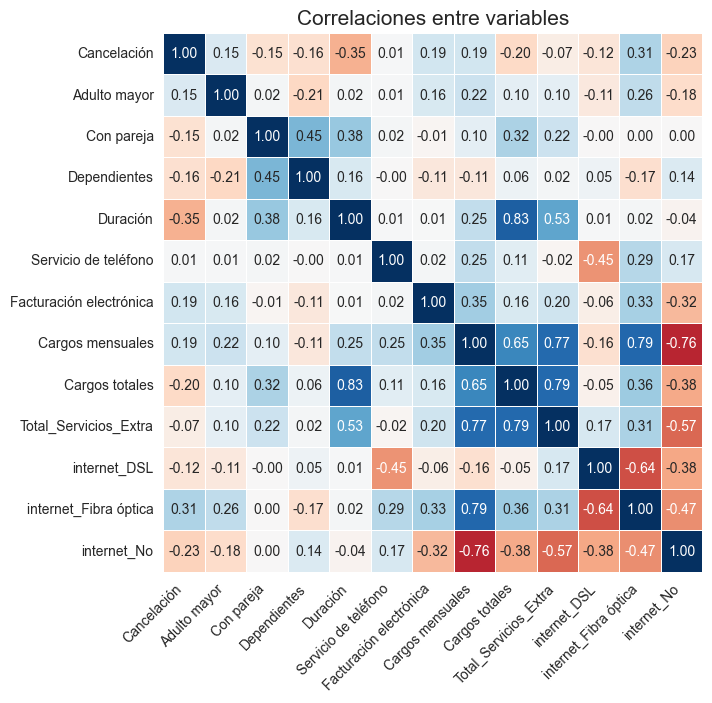

# Conclusiones e Insights

El análisis de cada variable revisada y su comparación con otras nos indica algunas tendencias en cuanto a los perfiles de los clientes y su tasa de cancelación, aquellos con pareja y dependientes son menos propensos a cancelar su servicio pero no tan significativamente. En cambio, hay una muy marcada tendencia a no cancelar entre los que tienen el gasto mensual menor, los que no tienen contrato mes a mes, y también la duración actúa como un factor de lealtad acumulada, donde el riesgo de abandono disminuye conforme el cliente supera la barrera de los primeros meses.

Además, la matriz de correlaciones aclara muchas de las observaciones que parecerían no tener mucho sentido o explicación, como la mayor tasa de cancelación en clientes con Fibra Óptica, así como por qué mayores cargos aumentan la tasa de cancelación a pesar de que una mayor cantidad de servicios extra la bajan: Los clientes con menos cancelaciones contratan más servicios de internet y DSL, pero no teléfono, buscando maximizar el costo-beneficio de su contrato al pagar menos por más servicios relacionados con internet solamente. La Fibra Óptica representa una fuga de clientes debido al precio, mientras que el DSL actúa como un "ancla" por su asequibilidad.

En conclusión, identificamos dos tipos de clientes con baja tasa de cancelación principalmente, aquellos que solo pagan los servicios básicos y su costo mensual es sumamente bajo, y aquellos que contratan mayor cantidad de servicios, pero solo con DSL, reduciendo su gasto mensual en comparación con los que tienen fibra óptica. Esto indica una clara tendencia a buscar ahorrar en el costo de su servicio.

# Recomendaciones

Al haber identificado los mayores predictores de cancelación con el análisis, podemos sugerir algunas estrategias para aumentar la retención:

- 🏷️ **Ofrecer planes cargados a precios atractivos:** Planes de internet sin servicio de teléfono y con costos reducidos por cada servicio extra contratado. Esto reducirá sus gastos y les dará un mayor costo-beneficio, a cambio de fidelización a largo plazo.
- 🔒 **Limitar los nuevos contratos mes a mes:** Este es un predictor mayor de cancelación, así que ofrecer incentivos para contratar a uno o dos años reducirá el churn. Se pueden hacer descuentos mayores u ofrecer servicios extra gratis por tiempo limitado en contratos a largo plazo. Así los clientes se acostumbran a tener estos servicios sin que suponga un gasto alto inicial.
- 🎖️ **Migración proactiva a contratos anuales:** Identificar a los clientes "mes a mes" que ya cumplieron 6 meses de antigüedad y ofrecerles el salto al contrato anual con una bonificación única, recompensando su lealtad.
- ✨ **Fibra óptica premium:** Implementar un programa de seguimiento intensivo durante los primeros 3 a 6 meses para los clientes de fibra óptica, y ofrecerles un valor agregado como mejor atención o beneficios extras no disponibles en DSL podría mitigar la sensación de un gasto excesivo al ser considerado un verdadero servicio "premium" para quienes buscan lo mejor.

Estas estrategias buscan desvincular la relación directa entre 'Costo Alto' y 'Cancelación', moviendo al cliente hacia estructuras de contrato más estables (Anuales) o de mayor valor percibido (Premium).